## We are going to make a simple neural network to classify the MNIST dataset using the keras library

In [5]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple/


In [6]:
import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras.layers import Dense , Flatten 
from tensorflow.keras import Sequential


In [7]:
(X_train ,y_train ) , (X_test , y_test) = keras.datasets.mnist.load_data()



In [8]:
X_train.shape , y_train.shape

((60000, 28, 28), (60000,))

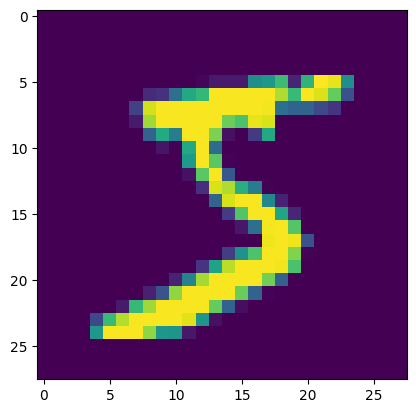

In [12]:
import matplotlib.pyplot as plt 

plt.imshow(X_train[0])


In [10]:
import sys
print(sys.executable)


c:\Users\manas\AppData\Local\Programs\Python\Python310\python.exe


In [11]:
import sys
!{sys.executable} -m pip install matplotlib



[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://pypi.org/simple/
     ---------------------------------------- 8.1/8.1 MB 1.6 MB/s eta 0:00:00
     -------------------------------------- 221.2/221.2 kB 3.3 MB/s eta 0:00:00
     ---------------------------------------- 73.7/73.7 kB 2.0 MB/s eta 0:00:00
     -------------------------------------- 122.8/122.8 kB 3.6 MB/s eta 0:00:00
     ---------------------------------------- 1.6/1.6 MB 2.9 MB/s eta 0:00:00


In [13]:
X_train = X_train / 255.0 
X_test = X_test / 255.0 



In [14]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [18]:
model = Sequential()

model.add(Flatten(input_shape = (28 , 28)))
model.add(Dense(128 , activation= 'relu'))
model.add(Dense(32 , activation='relu'))
model.add(Dense(10 , activation='softmax'))

from keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint('mnist_best_h5.keras' , monitor = 'val_accuracy' , save_best_only= True , mode = 'max' , verbose =1)

model.compile(optimizer = 'adam' , loss = 'sparse_categorical_crossentropy' , metrics = ['accuracy'])


C:\Users\manas\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:

from tabnanny import check


history = model.fit(X_train , y_train , epochs=15 , verbose = 1 , validation_data=(X_test , y_test) , callbacks = [checkpoint])


Epoch 1/15
1870/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8627 - loss: 0.4576
Epoch 1: val_accuracy improved from None to 0.96450, saving model to mnist_best_h5.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9249 - loss: 0.2531 - val_accuracy: 0.9645 - val_loss: 0.1261
Epoch 2/15
1867/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9662 - loss: 0.1138
Epoch 2: val_accuracy improved from 0.96450 to 0.97060, saving model to mnist_best_h5.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9682 - loss: 0.1063 - val_accuracy: 0.9706 - val_loss: 0.0959
Epoch 3/15
1872/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9779 - loss: 0.0749
Epoch 3: val_accuracy improved from 0.97060 to 0.97240, saving model to mnist_best_h5.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9775 - loss: 0.0749 - val_accuracy: 0.9724 - val_loss: 0.0911
Epoch 4/15
1863/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9831 - loss: 0.0535
Epoch 4: val_acc

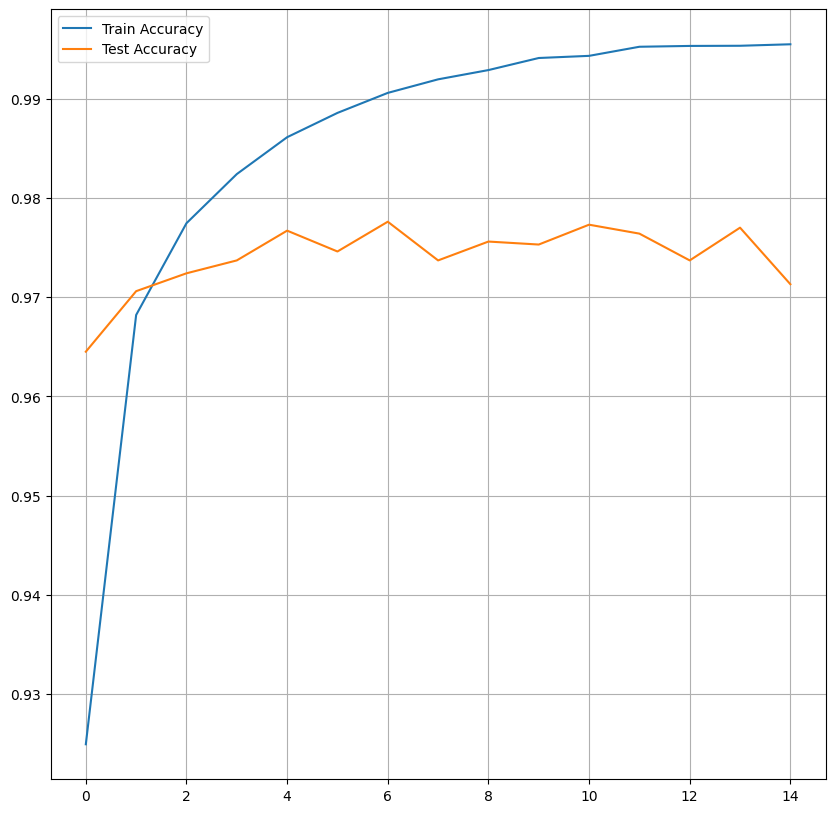

In [25]:
from tkinter import BaseWidget


plt.figure(figsize = (10 , 10), edgecolor='grey')
plt.plot(history.history['accuracy'] , label = 'Train Accuracy')
plt.plot(history.history['val_accuracy'] , label = 'Test Accuracy')
plt.legend()
plt.grid()
plt.show()


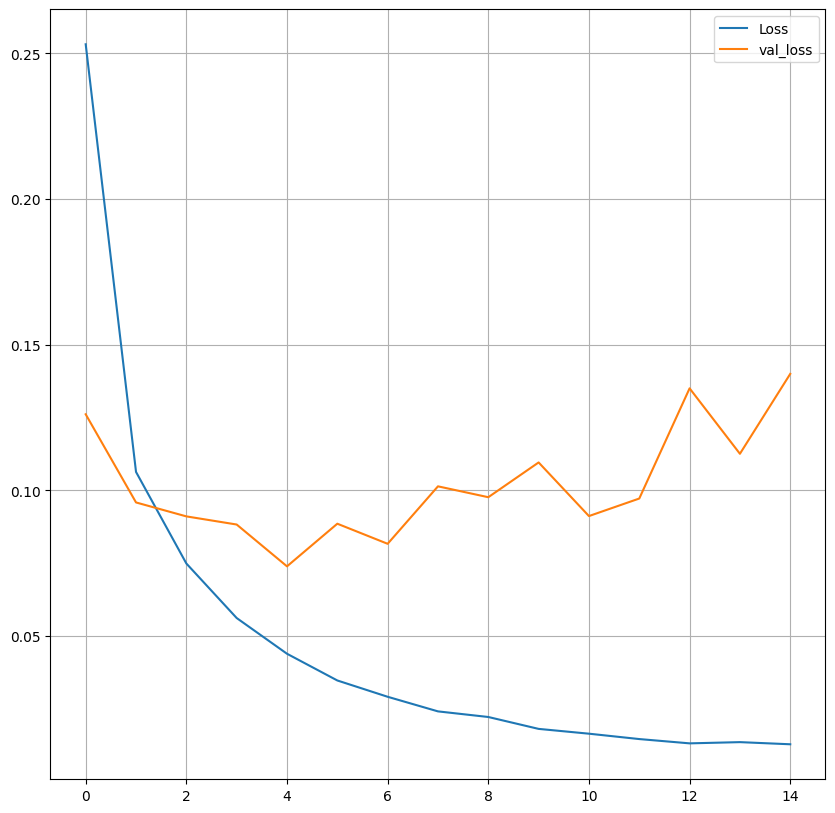

In [23]:
plt.figure(figsize=(10 , 10))
plt.plot(history.history['loss'] ,label = 'Loss')
plt.plot(history.history['val_loss'] , label = 'val_loss')
plt.legend()
plt.grid()
plt.show()


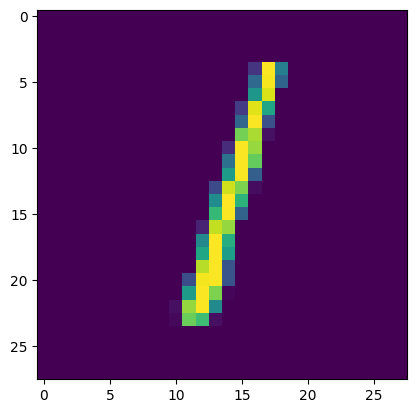

In [33]:
plt.imshow(X_test[2])

In [36]:
arr= model.predict(X_test[2].reshape(1,28 ,28))
arr.argmax(axis = 1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


array([1])